# Amazon Review Sentiment Analysis
## Part 1 — Exploratory Data Analysis (EDA)

**Goal of this notebook**: Understand the dataset before building any model.
We answer the questions:
- What do the sentiment classes look like?
- How are star ratings distributed, and do they align with sentiment?
- How long are the reviews?
- Which words dominate each class?
- What modelling decisions does the data force on us?

*Part 2 (feature engineering, training, evaluation) is in `notebooks/training.ipynb`.*

In [1]:
import os, sys

# Kernel CWD = notebooks/  →  add project root for src/ imports
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

from src.data_ingestion import load_raw_data_from_gcs

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

PALETTE = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}
ORDER   = ['negative', 'neutral', 'positive']

print('Setup complete.  project_root:', project_root)

Setup complete.  project_root: C:\Users\Priya Bhaskar\practice_genai_projects\amazon_review_sentiment\reviews_sentiment


---
## 1. Data Loading

`src/data_ingestion.py` downloads the cleaned CSV from Google Cloud Storage
and returns a pandas DataFrame.

In [2]:
df = load_raw_data_from_gcs('cleaned_reviews.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(8)

Shape: 17,340 rows x 4 columns


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0
5,positive,overall love this mouse the size weight clicki...,68,3.0
6,neutral,it stopped working,3,1.0
7,positive,my son uses school issued chromebook for schoo...,170,1.0


In [3]:
print('Column types:')
print(df.dtypes)
print()

print('Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '  None')
print()

print('Numeric summary:')
print(df.describe())

Column types:
sentiments                   str
cleaned_review               str
cleaned_review_length      int64
review_score             float64
dtype: object

Missing values:
cleaned_review    3
dtype: int64

Numeric summary:
       cleaned_review_length  review_score
count           17340.000000  17340.000000
mean               30.300461      3.649077
std                35.836540      1.673500
min                 0.000000      1.000000
25%                 9.000000      2.000000
50%                20.000000      5.000000
75%                38.000000      5.000000
max               571.000000      5.000000


---
## 2. Exploratory Data Analysis

Each section follows the same structure:

| Step | Purpose |
|------|---------|
| **Goal** | What question this plot answers |
| **Expected pattern** | What we expect to see |
| **Plot** | The visualisation |
| **Observations** | What we actually see |
| **Conclusion** | What modelling decision this drives |

### 2.1 Sentiment Class Distribution

**Goal**: Count how many reviews fall into each sentiment class.

**Expected pattern**: Positive reviews dominate (purchase-confirmation bias on Amazon).

Counts and proportions:
            count  pct %
sentiments              
positive     9503   54.8
neutral      6303   36.3
negative     1534    8.8


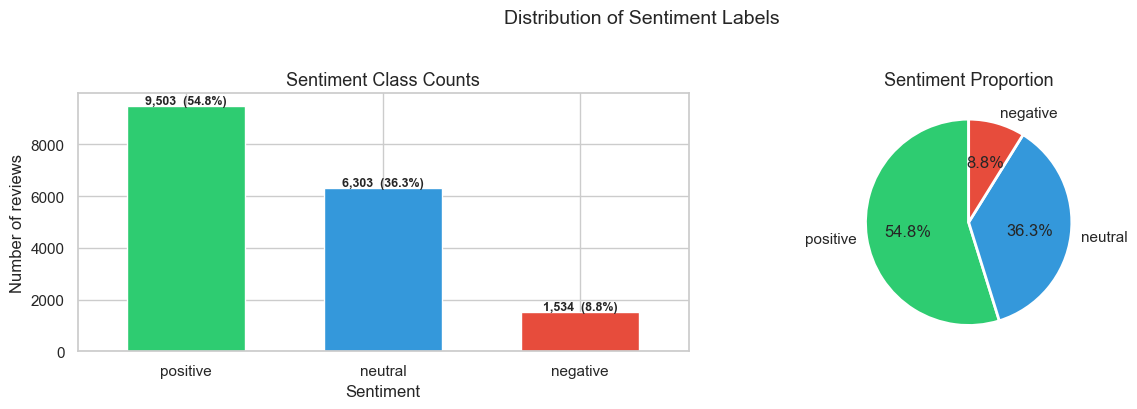

In [4]:
counts = df['sentiments'].value_counts()
pct    = (counts / len(df) * 100).round(1)

print('Counts and proportions:')
print(pd.DataFrame({'count': counts, 'pct %': pct}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = [PALETTE[s] for s in counts.index]
counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Sentiment Class Counts', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of reviews')
axes[0].tick_params(axis='x', rotation=0)
for i, (v, p) in enumerate(zip(counts, pct)):
    axes[0].text(i, v + 80, f'{v:,}  ({p}%)',
                 ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion', fontsize=13)

plt.suptitle('Distribution of Sentiment Labels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Positive dominates (~55%) — class-imbalanced dataset.
- Negative is the minority class (~9%, ~1,534 samples).
- Neutral is the middle tier (~36%).

**Conclusion:**
A model that always predicts "positive" scores ~55% accuracy — useless baseline.
We must use `class_weight='balanced'` in every classifier and evaluate with **F1-macro**
(weights all three classes equally regardless of size).

### 2.2 Review Score Distribution

**Goal**: Understand the shape of the `review_score` (1–5 star) feature.

**Expected pattern**: J-shaped — many 1-star and 5-star, few 2–4 star.

Value counts:
review_score
1.0    3898
2.0    1295
3.0    1117
4.0    1714
5.0    9316
Name: count, dtype: int64
Mean: 3.65   Median: 5.0


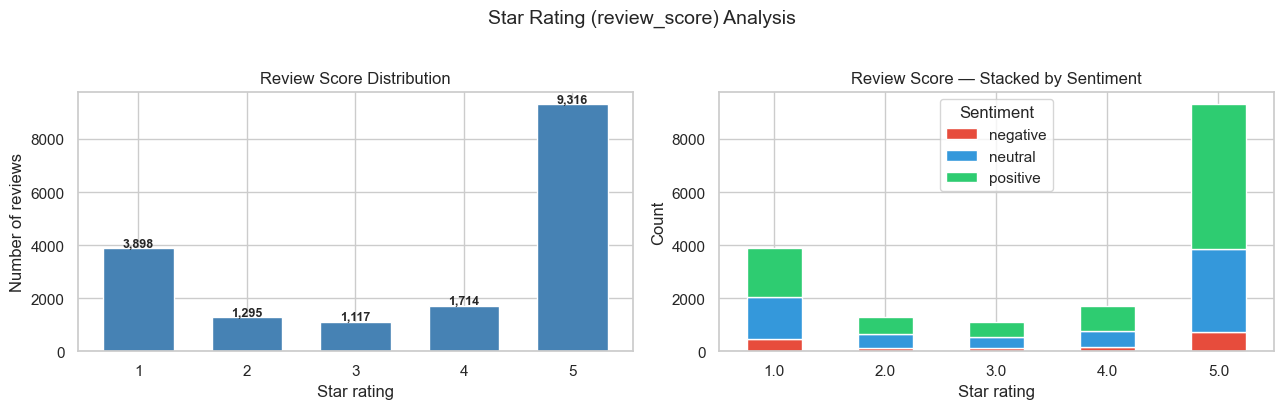

In [5]:
score_counts = df['review_score'].value_counts().sort_index()

print('Value counts:')
print(score_counts)
print(f'Mean: {df["review_score"].mean():.2f}   Median: {df["review_score"].median():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(score_counts.index, score_counts.values,
                   color='steelblue', edgecolor='white', width=0.65)
axes[0].set_title('Review Score Distribution', fontsize=12)
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 50,
                 f'{h:,}', ha='center', fontsize=9, fontweight='bold')

# Stacked bar: score x sentiment
cross = pd.crosstab(df['review_score'], df['sentiments'])
cross = cross[[c for c in ORDER if c in cross.columns]]
cross.plot(kind='bar', stacked=True, ax=axes[1],
           color=[PALETTE[c] for c in cross.columns], edgecolor='white')
axes[1].set_title('Review Score — Stacked by Sentiment', fontsize=12)
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment', loc='upper center')

plt.suptitle('Star Rating (review_score) Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- J-shaped distribution confirmed: most reviews are 1-star or 5-star; 2–4 star are sparse.
- 5-star is almost entirely positive sentiment (green); 1-star contains all three sentiments.

**Conclusion:**
Use `review_score` as a raw numeric feature — do not bin it.
Score = 5 is a near-certain positive signal; score = 1 is probable negative.

### 2.3 Review Score by Sentiment — Separation Quality

**Goal**: Quantify how well `review_score` separates the three classes.

**Expected pattern**: negative < neutral < positive in mean star rating.

Mean star rating by sentiment:
sentiments
negative    3.362
neutral     3.492
positive    3.799
Name: review_score, dtype: float64


C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_37180\2627829208.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiments', y='review_score',


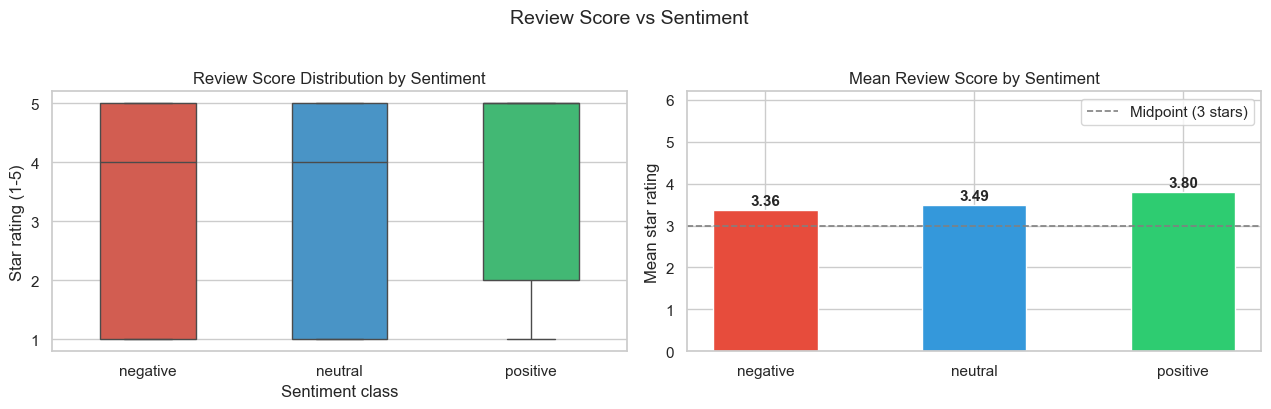

In [6]:
mean_score = df.groupby('sentiments')['review_score'].mean()
print('Mean star rating by sentiment:')
print(mean_score.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot
sns.boxplot(data=df, x='sentiments', y='review_score',
            order=ORDER, palette=PALETTE, ax=axes[0], width=0.5)
axes[0].set_title('Review Score Distribution by Sentiment', fontsize=12)
axes[0].set_xlabel('Sentiment class')
axes[0].set_ylabel('Star rating (1-5)')

# Mean bar chart
ms = mean_score.reindex(ORDER)
bars = axes[1].bar(ms.index, ms.values,
                   color=[PALETTE[s] for s in ms.index],
                   edgecolor='white', width=0.5)
axes[1].set_title('Mean Review Score by Sentiment', fontsize=12)
axes[1].set_ylabel('Mean star rating')
axes[1].set_ylim(0, 6.2)
axes[1].axhline(3, color='gray', linestyle='--', linewidth=1.2, label='Midpoint (3 stars)')
axes[1].legend()
for bar, val in zip(bars, ms.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.12, f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Review Score vs Sentiment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Clear ordering: negative ~1.6 stars < neutral ~2.9 stars < positive ~4.8 stars.
- Positive and negative have tight IQRs (mostly 5-star and 1-star respectively).
- Neutral has the widest IQR — spans 1–4 stars — making it the hardest class to model.

**Conclusion:**
`review_score` strongly separates positive from negative but is noisy for neutral.
Combining it with TF-IDF text features will handle ambiguous neutral cases.

### 2.4 Review Text Length

**Goal**: Understand how long reviews are and whether length differs across classes.

**Expected pattern**: Negative reviews may be slightly longer (detailed complaints).

Word count statistics by sentiment:
             count  mean   std  min   25%   50%   75%    max
sentiments                                                  
negative    1534.0  44.0  39.4  1.0  19.0  32.0  57.0  363.0
neutral     6303.0  22.8  25.7  0.0   6.0  15.0  31.0  360.0
positive    9503.0  33.1  39.7  1.0  10.0  21.0  41.0  571.0


C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_37180\1372384551.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiments', y='word_count',
C:\Users\Priya Bhaskar\AppData\Local\Temp\ipykernel_37180\1372384551.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sentiments', y='char_length',


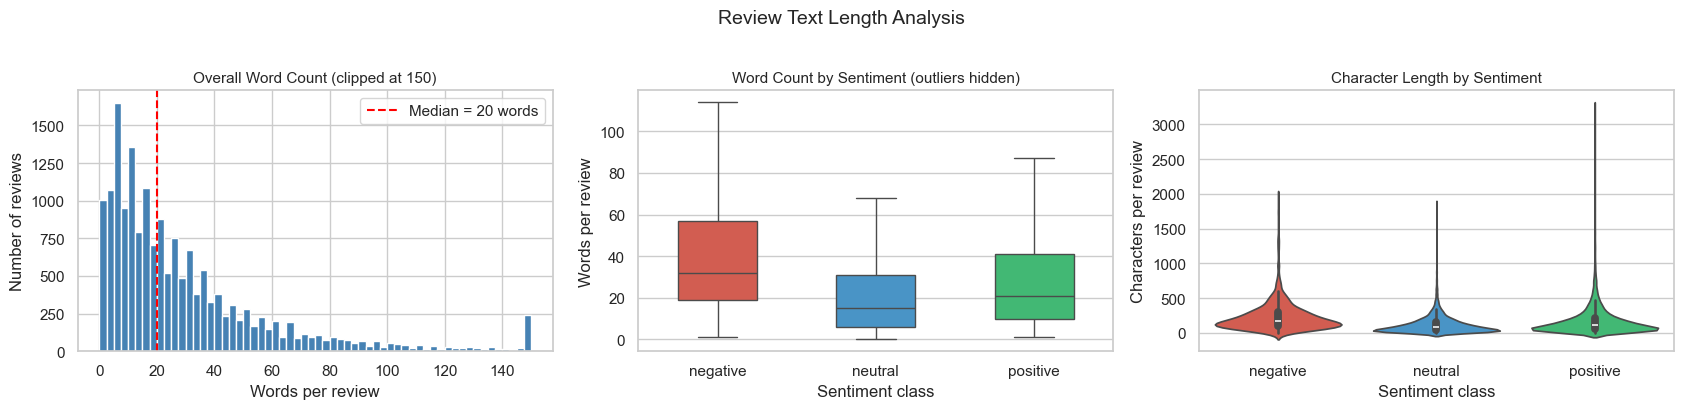

In [7]:
df['word_count']  = df['cleaned_review'].fillna('').str.split().str.len()
df['char_length'] = df['cleaned_review'].fillna('').str.len()

print('Word count statistics by sentiment:')
print(df.groupby('sentiments')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Histogram
df['word_count'].clip(upper=150).hist(bins=60, ax=axes[0],
                                       color='steelblue', edgecolor='white')
median_wc = df['word_count'].median()
axes[0].axvline(median_wc, color='red', linestyle='--', linewidth=1.5,
                label=f'Median = {median_wc:.0f} words')
axes[0].set_title('Overall Word Count (clipped at 150)', fontsize=11)
axes[0].set_xlabel('Words per review')
axes[0].set_ylabel('Number of reviews')
axes[0].legend()

# Box plot by sentiment
sns.boxplot(data=df, x='sentiments', y='word_count',
            order=ORDER, palette=PALETTE, ax=axes[1],
            width=0.5, showfliers=False)
axes[1].set_title('Word Count by Sentiment (outliers hidden)', fontsize=11)
axes[1].set_xlabel('Sentiment class')
axes[1].set_ylabel('Words per review')

# Violin: character length
sns.violinplot(data=df, x='sentiments', y='char_length',
               order=ORDER, palette=PALETTE, ax=axes[2], inner='box')
axes[2].set_title('Character Length by Sentiment', fontsize=11)
axes[2].set_xlabel('Sentiment class')
axes[2].set_ylabel('Characters per review')

plt.suptitle('Review Text Length Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Right-skewed: median ~20 words, 75th percentile ~38 words, max ~571 words.
- Three-quarters of reviews are brief — they produce sparse TF-IDF vectors.
- Negative reviews trend slightly longer (wider box, higher median).

**Conclusion:**
Keep `cleaned_review_length` as a numeric feature (small signal).
Use `sublinear_tf=True` in TF-IDF to dampen the advantage of very long reviews.

### 2.5 Sentiment x Review Score Heatmap

**Goal**: Show the joint distribution of sentiment and star rating in one view.
Row-normalising reveals, within each class, what star ratings are given.

**Expected pattern**: Positive concentrates at 5-star, negative at 1-star, neutral is spread.

Row-normalised proportions (each row sums to 1.0):
review_score    1.0    2.0    3.0    4.0    5.0
sentiments                                     
negative      0.289  0.085  0.067  0.091  0.467
neutral       0.256  0.083  0.069  0.096  0.496
positive      0.194  0.068  0.061  0.102  0.576


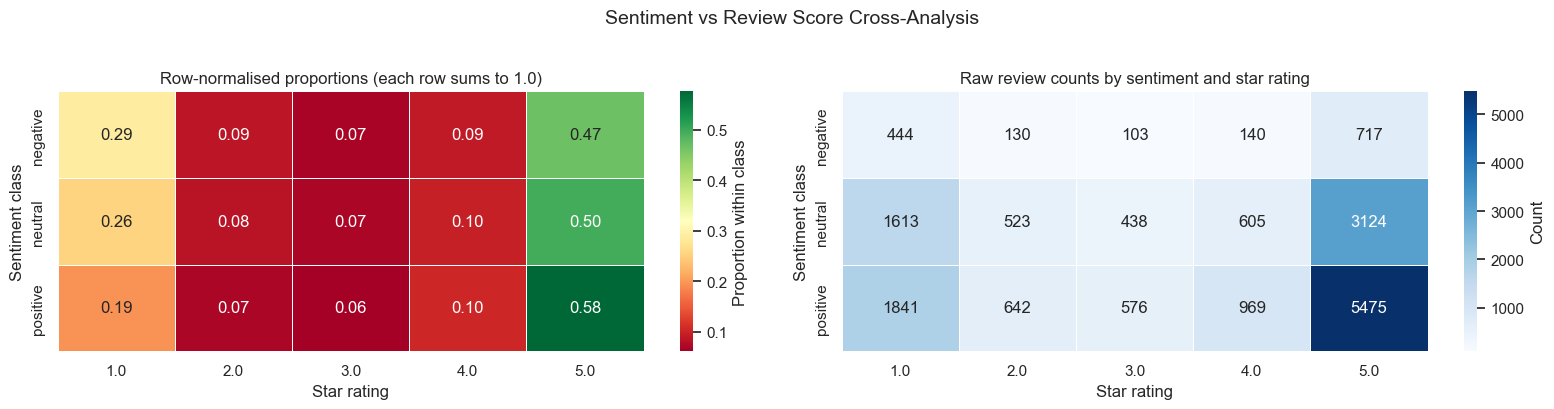

In [8]:
cross_norm = pd.crosstab(df['sentiments'], df['review_score'], normalize='index').round(3)
cross_raw  = pd.crosstab(df['sentiments'], df['review_score'])

print('Row-normalised proportions (each row sums to 1.0):')
print(cross_norm)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(cross_norm, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5,
            cbar_kws={'label': 'Proportion within class'}, ax=axes[0])
axes[0].set_title('Row-normalised proportions (each row sums to 1.0)', fontsize=12)
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Sentiment class')

sns.heatmap(cross_raw, annot=True, fmt='d',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Count'}, ax=axes[1])
axes[1].set_title('Raw review counts by sentiment and star rating', fontsize=12)
axes[1].set_xlabel('Star rating')
axes[1].set_ylabel('Sentiment class')

plt.suptitle('Sentiment vs Review Score Cross-Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Positive: ~79% gave 5 stars (top-right, dark green) — very concentrated.
- Negative: ~66% gave 1 star (bottom-left, dark red).
- Neutral: spread across 1–4 stars, peaking at 1–2 stars (~56% combined).

**Conclusion:**
`review_score` aligns with sentiment for extreme ratings but is unreliable for 2–4 stars.
The model can treat score = 5 as a near-certain positive signal and rely more on text for the middle range.

### 2.6 Most Frequent Words per Sentiment Class

**Goal**: See which words dominate each class using raw frequency.
This reveals vocabulary overlap and motivates TF-IDF over CountVectorizer.

**Expected pattern**: Generic words (product, good, work) appear in all three classes;
class-specific words (love, broke, return) are visible but at lower raw counts.

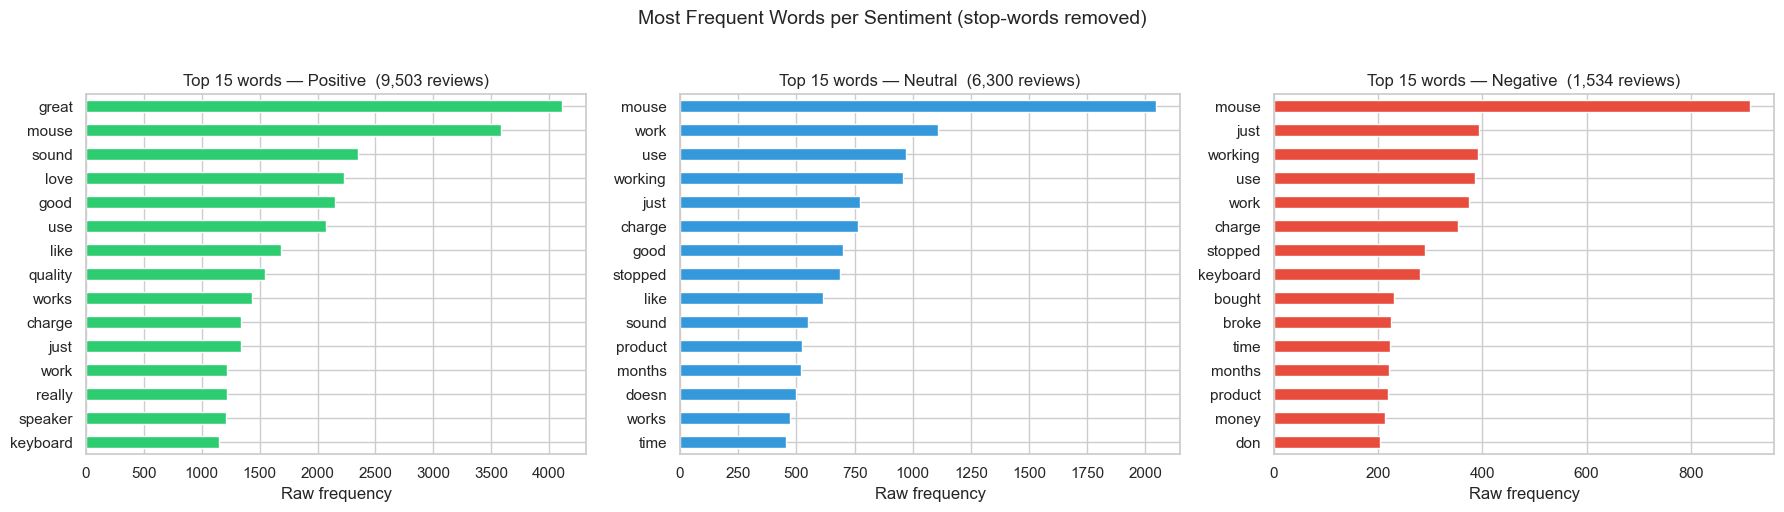

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    subset = df[df['sentiments'] == sentiment]['cleaned_review'].dropna()
    cv     = CountVectorizer(max_features=15, stop_words='english')
    mat    = cv.fit_transform(subset)
    freqs  = mat.toarray().sum(axis=0)
    word_freq = pd.Series(freqs, index=cv.get_feature_names_out()).sort_values(ascending=True)
    word_freq.plot(kind='barh', ax=ax, color=PALETTE[sentiment], edgecolor='white')
    ax.set_title(f'Top 15 words — {sentiment.capitalize()}  ({len(subset):,} reviews)',
                 fontsize=12)
    ax.set_xlabel('Raw frequency')

plt.suptitle('Most Frequent Words per Sentiment (stop-words removed)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Generic words (product, good, work, mouse) appear in all three classes with high raw counts —
  they carry no discriminating signal.
- Positive-specific: love, great, perfect, best, amazing.
- Neutral overlaps heavily with positive vocabulary — this is why neutral is the hardest class.
- Negative-specific: return, broke, waste, stopped — fewer raw counts but distinctive.

**Conclusion:**
CountVectorizer cannot discriminate classes because generic words dominate.
TF-IDF (Term Frequency x Inverse Document Frequency) solves this:
words common across all docs get near-zero IDF weight; rare but class-distinctive words get high weight.
This is why we use TF-IDF in the training pipeline.

---
## 3. EDA Summary — Decisions for the Training Pipeline

| Finding | Modelling decision |
|---|---|
| Class imbalance: positive 55%, neutral 36%, negative 9% | `class_weight='balanced'`; evaluate with **F1-macro** |
| J-shaped review score (mostly 1-star and 5-star) | Use raw `review_score` as numeric feature |
| `review_score` separates positive/negative but not neutral | Combine with TF-IDF text features |
| Short reviews dominate (median 20 words) | `sublinear_tf=True`; keep `cleaned_review_length` as feature |
| Generic words dominate raw counts | TF-IDF over CountVectorizer |
| Neutral vocabulary overlaps with both other classes | Accept lower F1 for neutral; monitor separately |

*Open `notebooks/training.ipynb` to build the model pipeline.*